In [ ]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"


In [3]:
print("hello world!")

hello world!


In [8]:
from matplotlib import pyplot as plt
import cartopy
import earthaccess
import numpy as np
import xarray as xr

Matplotlib is building the font cache; this may take a moment.


In [5]:
import os
directory_path = "/Users/ashrayuddaraju/Documents/nasaspaceapps/streamlit_tutorial/nasa_data/MODIS_AQUA_L3m_CHL_8D_9km/2003"
all_files = os.listdir(directory_path)


In [6]:
all_files

['AQUA_MODIS.20030101_20030108.L3m.8D.CHL.chlor_a.9km.nc',
 'AQUA_MODIS.20030125_20030201.L3m.8D.CHL.chlor_a.9km.nc',
 'AQUA_MODIS.20030109_20030116.L3m.8D.CHL.chlor_a.9km.nc',
 'AQUA_MODIS.20030210_20030217.L3m.8D.CHL.chlor_a.9km.nc',
 'AQUA_MODIS.20030117_20030124.L3m.8D.CHL.chlor_a.9km.nc']

In [17]:
def get_image_data(full_path):
    dataset = xr.open_dataset(full_path)
    # dataset
    array = np.log10(dataset["chlor_a"])
    array.attrs.update(
        {
            "units": f'log10({dataset["chlor_a"].attrs["units"]})',
        }
    )
    crs_proj = cartopy.crs.Robinson()
    crs_data = cartopy.crs.PlateCarree()
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_subplot(projection=crs_proj)
    array.plot(x="lon", y="lat", cmap="jet", ax=ax, robust=True, transform=crs_data)
    ax.coastlines()
    ax.set_title(dataset.attrs["product_name"])
    return plt.show()

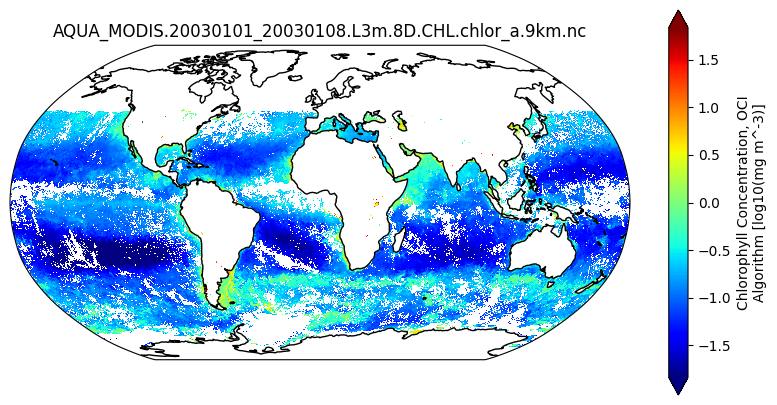

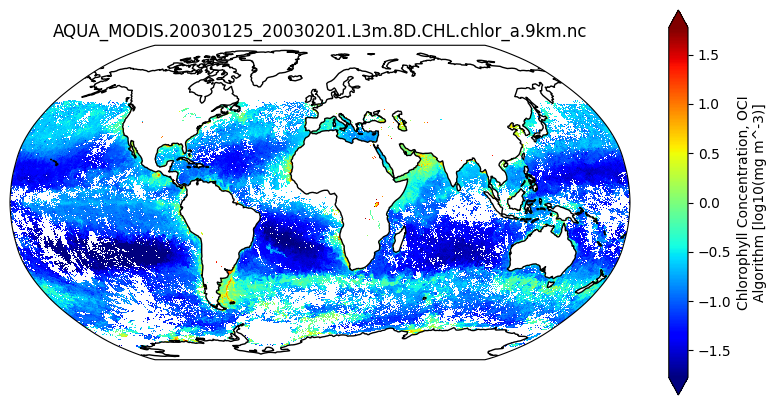

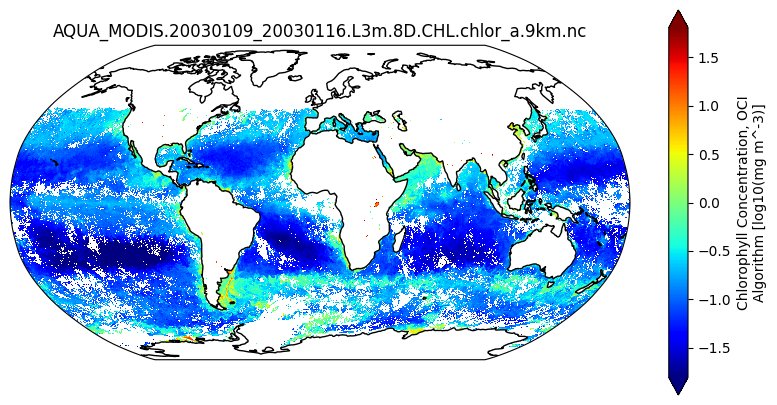

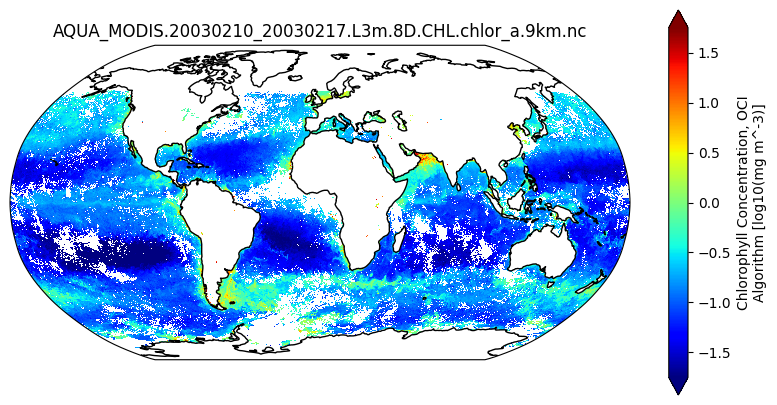

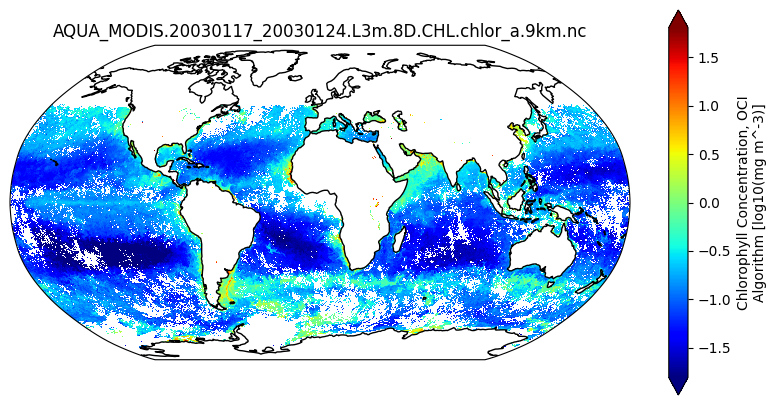

In [18]:
for file in all_files:
    full_path = os.path.join(directory_path, file)
    get_image_data(full_path)